In [12]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt


plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"


def QuickPlotGraph(df_, configs:list, 
                   independent_var:str, 
                   dependent_var:str, 
                   title:str=None, 
                   ind_label:str=None, 
                   dep_label:str=None, 
                   file_out:str=None, 
                   regression:bool=False, 
                   regression_label:bool=False,
                   fig_size:tuple=(8,6)):
    if ind_label is None:
        ind_label = independent_var
    if dep_label is None:
        dep_label = dependent_var
        
    df_a = df_.copy()
    df_a = df_a[df_a['Config_name'].isin(configs)]
    df_aa = (
        df_a
        .groupby(["Config_name", independent_var], as_index=False)[dependent_var]
        .mean()
        .sort_values(["Config_name", independent_var])
    )

    regression_results = {}
    regression_text = []

    fig, ax = plt.subplots(figsize=fig_size)
    for c, g in df_aa.groupby('Config_name', sort=False):
        x = g[independent_var].to_numpy(dtype=float)
        y = g[dependent_var].to_numpy(dtype=float)
        ax.scatter(x, y, alpha=0.75, label=latex_config_name(c))
        observed_line, = ax.plot(x, y, alpha=0.75)

        if regression:
            # log(y) is only defined for strictly positive y values.
            valid = (np.isfinite(x) & np.isfinite(y) & (y > 0))
            x_valid = x[valid]
            y_valid = y[valid]
            
            log_y = np.log(y_valid)

            # log(y) = intercept + growth_rate * x
            growth_rate, intercept = np.polyfit(x_valid, log_y, deg=1)

            scale = np.exp(intercept)

            predicted_log_y = (intercept + growth_rate * x_valid)

            residual_sum_of_squares = np.sum((log_y - predicted_log_y) ** 2)
            total_sum_of_squares = np.sum((log_y - log_y.mean()) ** 2)

            if np.isclose(total_sum_of_squares, 0):
                r_squared = np.nan
            else:
                r_squared = (1 - residual_sum_of_squares / total_sum_of_squares)

            regression_results[c] = { "a": scale, "b": growth_rate, "R_squared": r_squared}

            # Use a dense x range to draw a smooth exponential curve.
            regression_x = np.linspace(x_valid.min(), x_valid.max(), 200,)
            regression_y = scale * np.exp(growth_rate * regression_x) 

            ax.plot(
                regression_x,
                regression_y,
                linestyle="--",
                linewidth=2,
                alpha=0.9,
                color=observed_line.get_color(),
                label='__nolegend__',)
            
            regression_text.append(
                rf"{latex_config_name(c)}: "
                rf"$y={scale:.3g}e^{{{growth_rate:.3g}x}}$, "
                rf"$R^2={r_squared:.4f}$"
            )

    plt.yscale('log')  # Set the y-axis to logarithmic scale
    if (title is None):
        plt.title(f"{ind_label} vs {dep_label}")
    else:
        plt.title(title)

    plt.xlabel(ind_label)
    plt.ylabel(dep_label)

    ax.grid(True, alpha=0.3)
    ax.legend(title="Config", loc='upper left')

    if regression and regression_text and regression_label:
        regression_summary = "\n".join(regression_text)
        # Position the regression summary outside the plotting region.
        ax.text(1.03, 0.98, regression_summary,
            transform=ax.transAxes, va="top", ha="left",
            fontsize=11, linespacing=1.4,
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.9,},
        )
        # Reserve space on the right for the summary.
        fig.subplots_adjust(right=0.68)
    else:
        fig.tight_layout()

    plt.tight_layout() 
    if (not file_out is None):
        plt.savefig(f"{file_out}/{title}.png")
    plt.show()  # Show the plot
    

In [ ]:
defaultConfig = {"Horizon": 6}

nonMoralConfigs = {
    "(C)": {"Theories": [["Carla", "Utility", 0]], "Considerations": [["Carla", "Carla"], ["Cost"]]},
    "(N)^0": {
        "Theories": [["Necessity", "Ordinal", 0]], 
        "Considerations": [["Necessity", "Necessity"], ["Cost"]]
    },
    "(L)": {
        "Theories": [["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["OrdinalLaw", "OrdinalLaw"], ["Cost"]]
    },
    "(L)^0, (N)^0": {
        "Theories": [["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"], ["Cost"]]
    },
    "(C)^0, (N)^0, (L)^0": {
        "Theories": [["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0], ["Carla", "Utility", 0]], 
        "Considerations": [["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"], ["Cost"], ["Carla", "Carla"]]
    },
}

Config_repetitions=1
Environment_repetitions = 10

configs = []

min_budget = 3
step = 0.25
max_budget = 8
budget = min_budget
while (budget < max_budget):
    for name, dat in nonMoralConfigs.items():
        c = deepcopy(defaultConfig)
        c["Name"] = f"{budget}_{name}"
        c["Theories"] = dat["Theories"]
        c["Considerations"] = dat["Considerations"]
        c["Budget"] = budget
        c["Horizon"] = dat["Horizon"] if "Horizon" in dat.keys() else c["Horizon"]
        configs.append(c)
    budget += step

In [18]:
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../../", outFolder="NonMoral")

In [19]:
envs = er.buildEnvironments(configRepetitions=1)
er.runPlanner(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/NonMoral/mdps/3_(C)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Necessity', 'Type': 'Ordinal', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/NonMoral/mdps/3_(N)^0_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'OrdinalLaw', 'Type': 'Ordinal', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/NonMoral/mdps/3_(L)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Necessity', 'Type': 'Ordinal', 'Rank': 0}, {'Name': 'OrdinalLaw', 'Type': 'Ordinal', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/NonMoral/mdps/

In [42]:
data = []
for c in configs:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c["Name"], 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            x = json_data["Solutions"][json_data["Solutions_Order"][0]]["Expectation"]
            e = {
                "Config_name": c["Name"],
                "Env_rep" : env_rep,
                "Horizon": json_data["Horizon"],
                "Heuristic": json_data["Duration_Heuristic"],
                "Plan": json_data["Duration_Plan"],
                "Solution Extraction": json_data["Duration_Sols"],
                "MEHR": json_data["Duration_MEHR"],
                "Total" : json_data["Duration_Total"],
                "Total" : json_data["Duration_Total"],
                "Solutions" : len(json_data["Solutions"]),
                "Total policies": json_data["Total_reachable_policies"],
                "Cost": x["Cost"],
                "Carla": x["Carla"] if "Carla" in x.keys() else np.nan,
                "Legal": x["Legal"] if "Legal" in x.keys() else np.nan,
                "Necessity": x["Necessity"] if "Necessity" in x.keys() else np.nan,
            }
            data.append(e)
time_cols = ["Heuristic", "Plan", "Solution Extraction", "MEHR", "Total"]
df = pd.DataFrame(data)
df["Budget"] = pd.to_numeric(
    df["Config_name"]
    .str.extract(r"^(\d+(?:\.\d+)?)_", expand=False)
    .astype(float))

/tmp/ipykernel_95224/1166111096.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Config", loc='upper left')


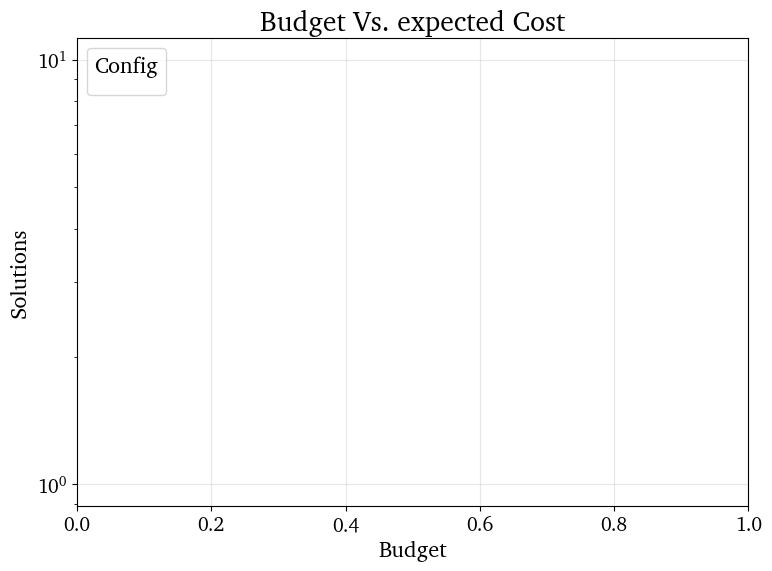

In [ ]:
QuickPlotGraph(df, ["(C)^0, (N)^0, (L)^0"], "Budget", "Solutions", title="Budget Vs. expected Cost", file_out=er.figuresFolder)

In [27]:
cols = ["Carla", "Necessity", "Legality", "Cost"]
worth_df = pd.DataFrame(er.GetWorthData(worth_tags=cols, envRepetitions=1))
for t in ["Cost", "Carla"]:
    worth_df[t] = pd.to_numeric(worth_df[t])
worth_df = worth_df.drop(columns=["Conf_rep"])
worth_df["Budget"] = pd.to_numeric(
    worth_df["Config_name"]
    .str.extract(r"^(\d+(?:\.\d+)?)_", expand=False)
    .astype(float)
)
#worth_df["Config_name"] = worth_df["Config_name"].str[2:]
df = worth_df.copy()
worth_df = worth_df.groupby(['Config_name', 'Env_rep'], sort=False, as_index=False).head(50)

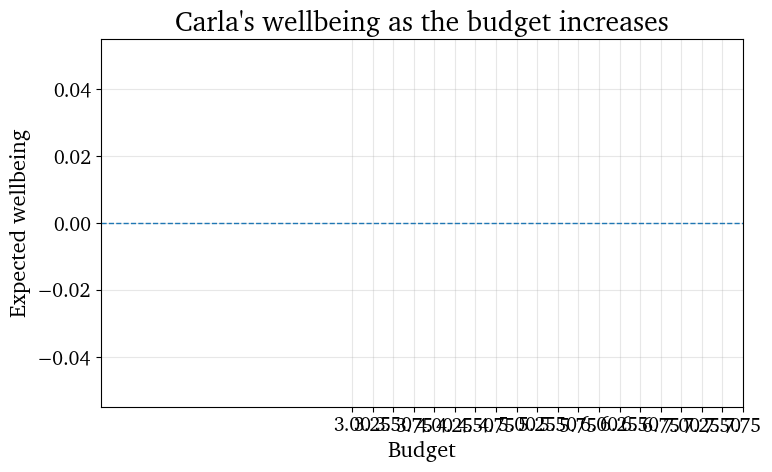

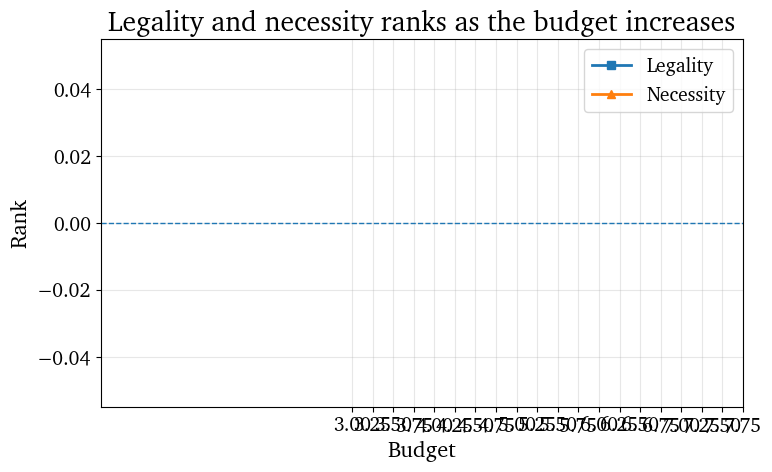

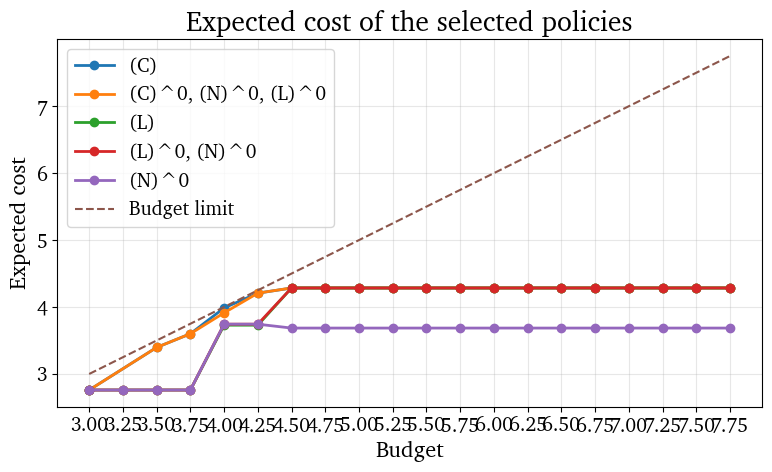

In [22]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plot_df = worth_df.copy()


# ---------------------------------------------------------------------
# Prepare the data
# ---------------------------------------------------------------------

# Ensure the numeric columns really are numeric.
plot_df["Budget"] = pd.to_numeric(
    plot_df["Budget"],
    errors="coerce",
)

plot_df["Cost"] = pd.to_numeric(
    plot_df["Cost"],
    errors="coerce",
)

plot_df["Carla"] = pd.to_numeric(
    plot_df["Carla"],
    errors="coerce",
)


# Remove the numeric prefix from Config_name:
# "3.25_(Carla)" -> "(Carla)"
plot_df["Environment"] = plot_df["Config_name"].str.replace(
    r"^-?\d+(?:\.\d+)?_",
    "",
    regex=True,
)

plot_df["Environment"] = plot_df["Environment"].replace({
    "(Carla)": "Carla",
    "(Law)^0, (Necessity)^0": "Legality + Necessity",
})


def extract_rank(value):
    """Convert a value such as 'R=-5' into -5.0."""
    if pd.isna(value):
        return np.nan

    match = re.search(
        r"R\s*=\s*(-?\d+(?:\.\d+)?)",
        str(value),
    )

    return float(match.group(1)) if match else np.nan


plot_df["Legality_rank"] = plot_df["Legality"].map(extract_rank)
plot_df["Necessity_rank"] = plot_df["Necessity"].map(extract_rank)


# Cost is stored as negative worth, so turn it into positive expected cost.
plot_df["Expected_cost"] = -plot_df["Cost"]


# ---------------------------------------------------------------------
# Remove policies whose expected cost exceeds the budget
# ---------------------------------------------------------------------

# The tolerance avoids removing values due only to floating-point noise,
# e.g. 3.2500000000001 compared with a budget of 3.25.
tolerance = 1e-9

plot_df = plot_df.loc[
    plot_df["Expected_cost"]
    <= plot_df["Budget"] + tolerance
].copy()


# ---------------------------------------------------------------------
# Aggregate repeated experiments
# ---------------------------------------------------------------------

summary = (
    plot_df
    .groupby(
        ["Environment", "Budget"],
        as_index=False,
    )
    .agg(
        Carla=("Carla", "mean"),
        Legality_rank=("Legality_rank", "mean"),
        Necessity_rank=("Necessity_rank", "mean"),
        Expected_cost=("Expected_cost", "mean"),
    )
    .sort_values(["Environment", "Budget"])
)


# Use every available budget as an x-axis tick.
budget_ticks = np.sort(
    summary["Budget"].dropna().unique()
)


# ---------------------------------------------------------------------
# Plot 1: Carla's wellbeing
# ---------------------------------------------------------------------

carla_data = (
    summary.loc[
        summary["Environment"].eq("Carla")
        & summary["Carla"].notna()
    ]
    .sort_values("Budget")
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    carla_data["Budget"],
    carla_data["Carla"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_title("Carla's wellbeing as the budget increases")
ax.set_xlabel("Budget")
ax.set_ylabel("Expected wellbeing")
ax.set_xticks(budget_ticks)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Plot 2: Legality and Necessity ranks
# ---------------------------------------------------------------------

moral_data = (
    summary.loc[
        summary["Environment"].eq("Legality + Necessity")
    ]
    .sort_values("Budget")
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    moral_data["Budget"],
    moral_data["Legality_rank"],
    marker="s",
    linewidth=2,
    label="Legality",
)

ax.plot(
    moral_data["Budget"],
    moral_data["Necessity_rank"],
    marker="^",
    linewidth=2,
    label="Necessity",
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_title("Legality and necessity ranks as the budget increases")
ax.set_xlabel("Budget")
ax.set_ylabel("Rank")
ax.set_xticks(budget_ticks)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Plot 3: Expected cost
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

for environment, group in summary.groupby("Environment"):
    group = group.sort_values("Budget")

    ax.plot(
        group["Budget"],
        group["Expected_cost"],
        marker="o",
        linewidth=2,
        label=environment,
    )


# Plot the budget itself as a reference line.
ax.plot(
    budget_ticks,
    budget_ticks,
    linestyle="--",
    linewidth=1.5,
    label="Budget limit",
)

ax.set_title("Expected cost of the selected policies")
ax.set_xlabel("Budget")
ax.set_ylabel("Expected cost")
ax.set_xticks(budget_ticks)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()